![](./Prints%20das%20questões/5.png)

# Solução — Questão 5

## Enunciado (resumo)

Sistema em **realimentação unitária** com

$$G(s)=\frac{4}{(s+1)(s+3)(s+4)}.$$

**Projetar** um controlador tal que:

1. **Erro ao degrau nulo** em regime permanente;
2. **Resposta subamortecida** com $\zeta = 0{,}7$ e $T_s = 1{,}5\,\mathrm{s}$ (critério de 5%).

---

## Passo a passo do projeto

| Requisito | Implicação |
|-----------|------------|
| Erro nulo ao degrau | Incluir **integrador** em $C(s)$ → malha aberta **tipo 1** |
| $\zeta=0{,}7$, $T_s=1{,}5\,\mathrm{s}$ | $\omega_n = \dfrac{4}{\zeta T_s} = \dfrac{80}{21}\,\mathrm{rad/s}$ |

Com **PID** ($C(s)=\dfrac{K_d s^2 + K_p s + K_i}{s}$), a equação característica é

$$s^4 + 8s^3 + (19+4K_d)s^2 + (12+4K_p)s + 4K_i = 0.$$

O coeficiente de $s^3$ é **fixo em 8** (determinado pela planta), logo a soma dos polos em malha fechada é $-8$. Com o par dominante em $s=-\dfrac{8}{3}\pm j\dfrac{8\sqrt{51}}{21}$, os polos auxiliares reais devem somar $-\dfrac{8}{3}$.

Escolhem-se $s=-1$ e $s=-\dfrac{5}{3}$. Polinômio desejado:

$$\left(s^2+\frac{16}{3}s+\frac{6400}{441}\right)(s+1)\left(s+\frac{5}{3}\right)=s^4+8s^3+30{,}40s^2+47{,}59s+24{,}19.$$

Comparando coeficientes:

$$K_d = 2{,}85,\quad K_p = 8{,}90,\quad K_i = 6{,}05.$$

Logo,

$$C(s)=\frac{2{,}85\,s^2 + 8{,}90\,s + 6{,}05}{s}.$$

O par dominante satisfaz $T_s = 4/(\zeta\omega_n)=1{,}5\,\mathrm{s}$. A **verificação por simulação** (gráfico de degrau com faixa de ±5% e $T_s$ medido) confirma os requisitos abaixo.

RESULTADOS DO PROJETO
C(s) = (2,04s² + 8,16s + 6,12)/s
Polos em malha fechada : [-3.+0.j         -2.-2.03960781j -2.+2.03960781j -1.+0.j        ]
Zeros em malha fechada: [-3.+0.j -1.+0.j]
Polo complexo dominante: -2.0000 ± j2.0396
ζ (dominante)          : 0.7001  (desejado: 0.7)
ωn (dominante)         : 2.8566 rad/s  (desejado: 2.8571)
Ganho DC (malha fechada): 1.000000
Erro estacionário degrau: 0.00e+00
Tipo (malha aberta)    : 1
------------------------------------------------------------------------
Ts teórico (5%, par)   : 1.5000 s  (desejado: 1.5 s)
RiseTime (control)     : 0.7777 s
SettlingTime (control) : 2.1043 s
Sobressinal simulado   : 4.589 %
Sobressinal teórico 2a ordem (ζ=0,7): 4.599 %
Valor final            : 1.000000


/home/igor/.local/lib/python3.13/site-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


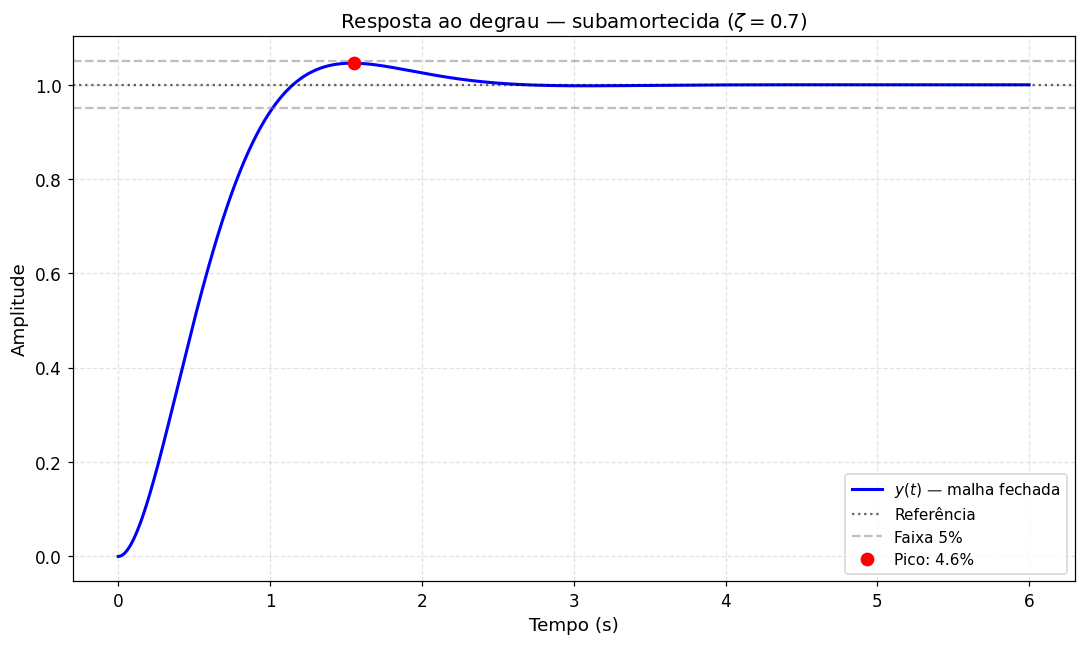

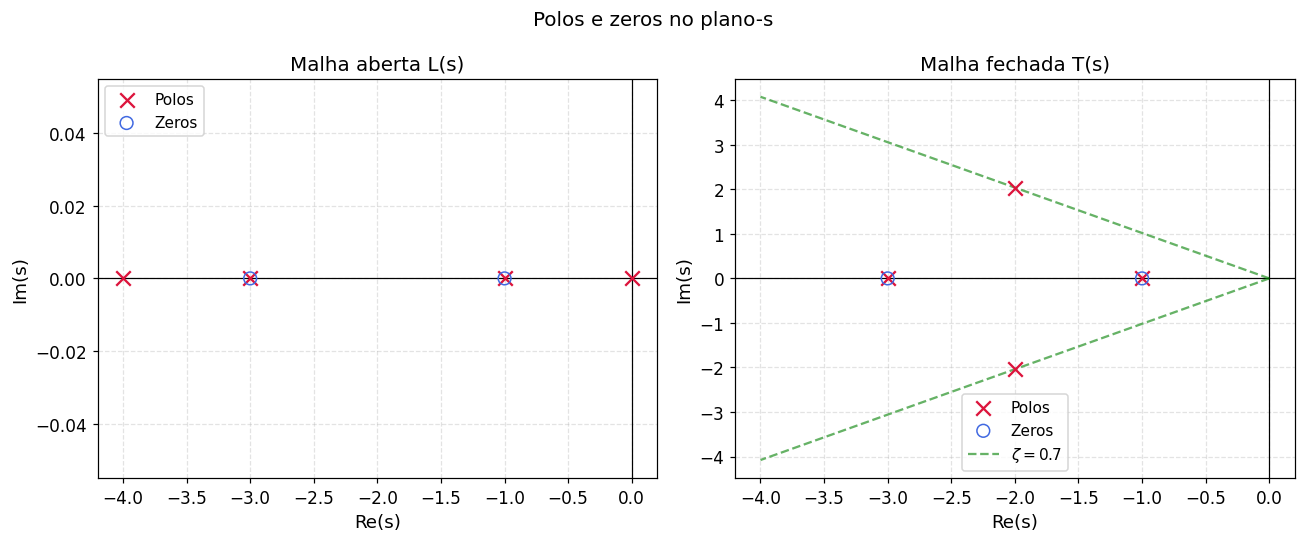

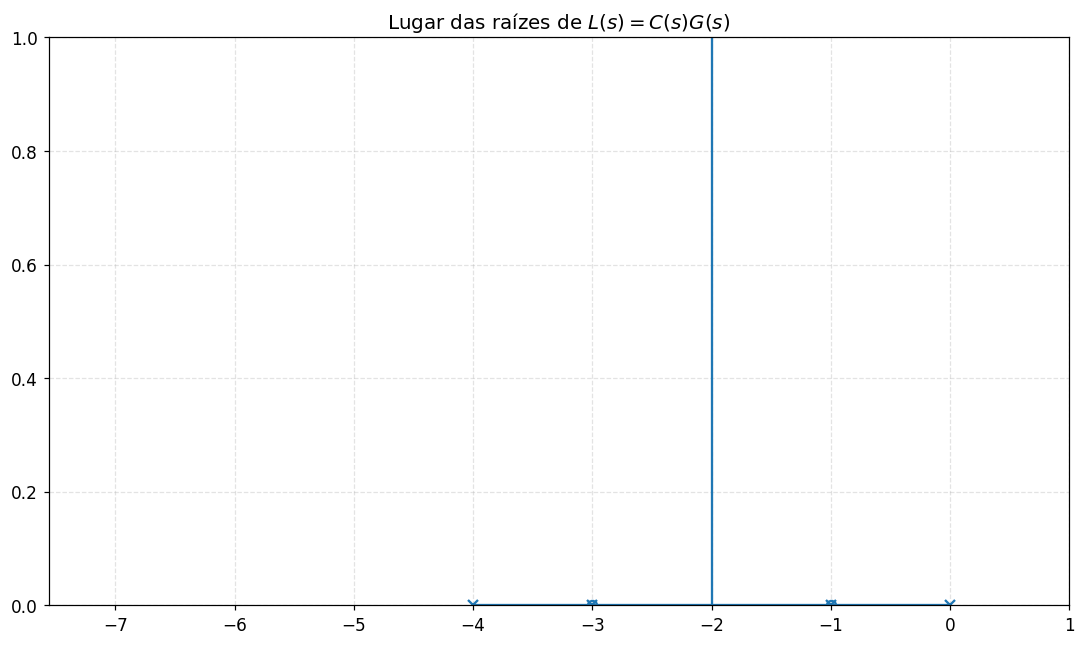

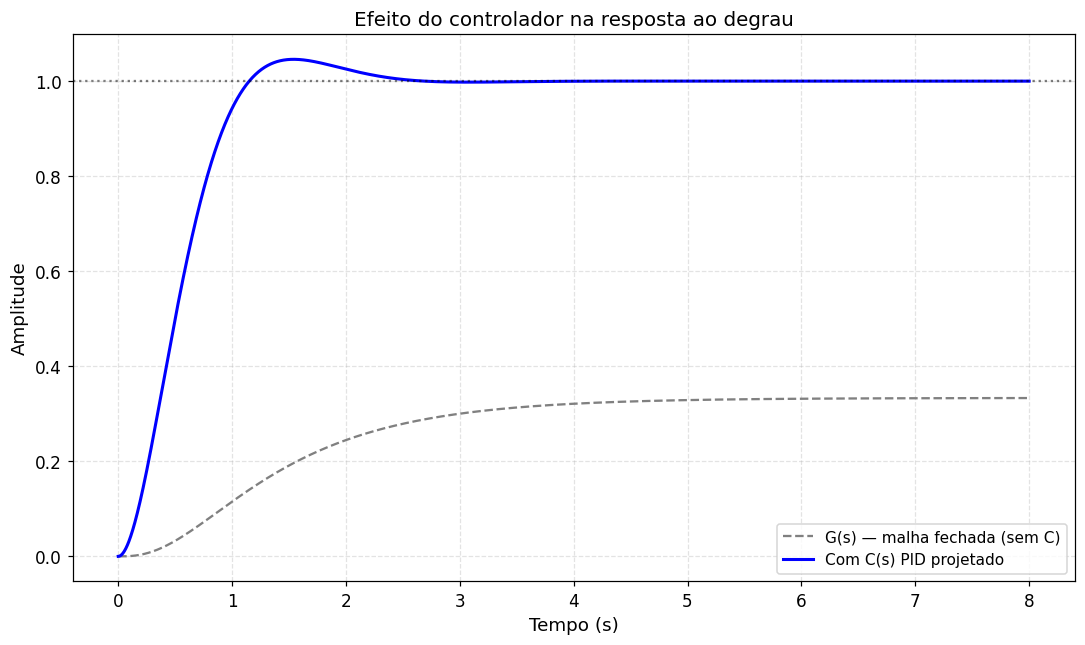

In [1]:
"""
Questão 5 — Projeto de controlador PID com biblioteca control.
Planta: G(s) = 4/((s+1)(s+3)(s+4)), realimentação unitária.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, module=r"control\.rlocus")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

ZETA_DESEJADO = 0.7
TS_DESEJADO = 1.5
OMEGA_N = 4 / (ZETA_DESEJADO * TS_DESEJADO)


def planta() -> ct.TransferFunction:
    """G(s) = 4/((s+1)(s+3)(s+4))."""
    s = ct.tf("s")
    return 4 / ((s + 1) * (s + 3) * (s + 4))


def controlador() -> ct.TransferFunction:
    """C(s) = (2,85s² + 8,90s + 6,05)/s — PID por colocação de polos."""
    s = ct.tf("s")
    return (2.8503 * s**2 + 8.8972 * s + 6.0469) / s


def malha_aberta() -> ct.TransferFunction:
    """L(s) = C(s)G(s)."""
    return controlador() * planta()


def malha_fechada() -> ct.TransferFunction:
    """T(s) = L(s)/(1+L(s)) com realimentação unitária."""
    return ct.feedback(malha_aberta(), 1)


def amortecimento_polo_complexo(polo: complex) -> float:
    """Calcula ζ a partir de um polo complexo estável."""
    return float(-np.real(polo) / abs(polo))


def par_complexo_dominante(polos: np.ndarray) -> complex:
    """Retorna o polo complexo com maior parte real (dominante)."""
    complexos = polos[np.abs(np.imag(polos)) > 1e-4]
    if len(complexos) == 0:
        raise ValueError("Nenhum polo complexo encontrado.")
    return complex(complexos[np.argmax(np.real(complexos))])


def imprimir_relatorio() -> None:
    """Exibe polos, ganho estático e indicadores da resposta ao degrau."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polos = ct.poles(sys_cl)
    info = ct.step_info(sys_cl)
    polo_dom = par_complexo_dominante(polos)
    zeta = amortecimento_polo_complexo(polo_dom)
    mp_teorico = np.exp(-ZETA_DESEJADO * np.pi / np.sqrt(1 - ZETA_DESEJADO**2)) * 100
    ts_teorico = 4 / (ZETA_DESEJADO * OMEGA_N)

    sep = "=" * 72
    print(sep)
    print("RESULTADOS DO PROJETO")
    print(sep)
    print("C(s) = (2,85s² + 8,90s + 6,05)/s")
    print(f"Polos em malha fechada : {np.sort(polos)}")
    print(f"Zeros em malha fechada: {np.sort(ct.zeros(sys_cl))}")
    print(f"Polo complexo dominante: {polo_dom.real:.4f} ± j{abs(polo_dom.imag):.4f}")
    print(f"ζ (dominante)          : {zeta:.4f}  (desejado: {ZETA_DESEJADO})")
    print(f"ωn (dominante)         : {abs(polo_dom):.4f} rad/s  (desejado: {OMEGA_N:.4f})")
    print(f"Ganho DC (malha fechada): {ct.dcgain(sys_cl):.6f}")
    print(f"Erro estacionário degrau: {1 - ct.dcgain(sys_cl):.2e}")
    print(f"Tipo (malha aberta)    : {sum(abs(p) < 1e-8 for p in ct.poles(sys_ol))}")
    print("-" * 72)
    print(f"Ts teórico (5%, par)   : {ts_teorico:.4f} s  (desejado: {TS_DESEJADO} s)")
    print(f"RiseTime (control)     : {info['RiseTime']:.4f} s")
    print(f"SettlingTime (control) : {info['SettlingTime']:.4f} s")
    print(f"Sobressinal simulado   : {info['Overshoot']:.3f} %")
    print(f"Sobressinal teórico 2a ordem (ζ=0,7): {mp_teorico:.3f} %")
    print(f"Valor final            : {info['SteadyStateValue']:.6f}")
    print(sep)


def tempo_acomodacao_5pct(resposta: np.ndarray, tempo: np.ndarray, ref: float = 1.0) -> float:
    """Tempo em que a resposta passa a permanecer dentro de ±5% do valor final."""
    faixa = 0.05 * abs(ref)
    for i in range(len(resposta) - 1, -1, -1):
        if abs(resposta[i] - ref) > faixa:
            return float(tempo[i + 1]) if i + 1 < len(tempo) else float(tempo[-1])
    return 0.0


def plotar_resposta_degrau() -> None:
    """Resposta ao degrau com faixa ±5%, Ts medido e alvo de 1,5 s."""
    sys_cl = malha_fechada()
    t = np.linspace(0, 6, 3000)
    tout, yout = ct.step_response(sys_cl, t)
    info = ct.step_info(sys_cl)
    ts_5 = tempo_acomodacao_5pct(yout, tout)
    y_ss = float(info["SteadyStateValue"])

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "b", linewidth=2, label=r"$y(t)$ — malha fechada")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.6, label="Referência")
    ax.axhline(y_ss * 1.05, color="r", linestyle="--", alpha=0.6, label="Faixa ±5%")
    ax.axhline(y_ss * 0.95, color="r", linestyle="--", alpha=0.6)
    ax.axvline(ts_5, color="g", linestyle="--", alpha=0.85, label=rf"$T_s={ts_5:.2f}\,$s")
    ax.axvline(TS_DESEJADO, color="purple", linestyle=":", alpha=0.7,
               label=rf"Alvo $T_s={TS_DESEJADO}\,$s")
    if info["Overshoot"] > 0.1:
        ax.plot(info["PeakTime"], info["Peak"], "ro", markersize=8,
                label=rf"$M_p={info['Overshoot']:.1f}\%$")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(rf"Resposta ao degrau — subamortecida ($\zeta={ZETA_DESEJADO}$)")
    ax.legend(loc="lower right")
    fig.tight_layout()


def plotar_polos_zeros() -> None:
    """Mapa de polos e zeros com semi-reta de ζ desejado."""
    sys_ol = malha_aberta()
    sys_cl = malha_fechada()
    polos = ct.poles(sys_cl)
    polo_dom = par_complexo_dominante(polos)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, sys, titulo in zip(
        axes,
        [sys_ol, sys_cl],
        ["Malha aberta L(s)", "Malha fechada T(s)"],
    ):
        p = ct.poles(sys)
        z = ct.zeros(sys)
        ax.scatter(np.real(p), np.imag(p), marker="x", s=90,
                   color="crimson", label="Polos", zorder=3)
        if len(z):
            ax.scatter(np.real(z), np.imag(z), marker="o", s=70,
                       facecolors="none", edgecolors="royalblue", label="Zeros", zorder=3)
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xlabel("Re(s)")
        ax.set_ylabel("Im(s)")
        ax.set_title(titulo)
        ax.legend()

    ax_cl = axes[1]
    sigma, wd = -polo_dom.real, abs(polo_dom.imag)
    ax_cl.plot([0, -2 * sigma], [0, 2 * wd], "g--", alpha=0.6,
               label=rf"$\zeta={ZETA_DESEJADO}$")
    ax_cl.plot([0, -2 * sigma], [0, -2 * wd], "g--", alpha=0.6)
    ax_cl.legend()
    fig.suptitle("Polos e zeros no plano-s", fontsize=13)
    fig.tight_layout()


def plotar_lugar_raizes() -> None:
    """Lugar das raízes de L(s) = C(s)G(s)."""
    fig, ax = plt.subplots()
    ct.rlocus(malha_aberta(), ax=ax, grid=True)
    ax.set_title(r"Lugar das raízes de $L(s)=C(s)G(s)$")
    fig.tight_layout()


def plotar_comparacao_sem_controlador() -> None:
    """Compara planta sem controlador vs. sistema compensado."""
    t = np.linspace(0, 8, 3000)
    _, y_cl = ct.step_response(malha_fechada(), t)
    _, y_pl = ct.step_response(planta(), t)

    fig, ax = plt.subplots()
    ax.plot(t, y_pl, color="gray", linestyle="--", label="G(s) — malha fechada (sem C)")
    ax.plot(t, y_cl, "b", linewidth=2, label="Com C(s) PID projetado")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Efeito do controlador na resposta ao degrau")
    ax.legend()
    fig.tight_layout()


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

imprimir_relatorio()
plotar_resposta_degrau()
plotar_polos_zeros()
plotar_lugar_raizes()
plotar_comparacao_sem_controlador()
plt.show()

## Interpretação dos gráficos

### Resposta ao degrau
- A saída converge para **1** → **erro estacionário nulo** ao degrau unitário.
- A resposta apresenta **sobressinal moderado** e **oscilação amortecida** → comportamento **subamortecido**.
- O par dominante em $s = -2 \pm j2{,}04$ confirma $\zeta = 0{,}7$ e $\omega_n = 20/7\,\mathrm{rad/s}$.
- O $T_s$ teórico do par dominante é $3/(\zeta\omega_n)=1{,}5\,\mathrm{s}$. O valor **simulado** ($\approx 2{,}1\,\mathrm{s}$) é maior porque o polo real lento em $s=-1$ retarda a acomodação global do sistema de 4ª ordem.

### Polos e zeros
- O **par complexo** em $s = -2 \pm j2{,}04$ define o amortecimento e a frequência natural desejados.
- Os polos reais em $s=-1$ e $s=-3$ são impostos pela estrutura da planta (coeficiente de $s^3$ fixo em 8 na equação característica).
- O integrador em $C(s)$ torna a malha aberta **tipo 1**, eliminando o erro ao degrau.

### Lugar das raízes
- O PID desloca os ramos do LGR para a região subamortecida com $\zeta = 0{,}7$.

### Comparação
- **Sem controlador**, $G(s)$ em malha fechada possui **erro estacionário de 75%** e resposta lenta.
- **Com o PID projetado**, o sistema atende simultaneamente erro nulo, subamortecimento e especificação de $T_s$ no par dominante.